# 01 · Set up a project and explore the data

**Use case:** a data team gets three CSV exports from a bookstore's review system (`customer`, `product`, `review`)
and wants them queryable, joined and charted in minutes — with no ETL.

**Sub-tasks**
1. Sign in with an API key (`langsat login` or `LANGSAT_API_KEY`)
2. Create a project, upload the three CSVs
3. Let Langsat detect primary keys, foreign keys and time columns
4. See what a clean would cost, then clean (free under 500K rows)
5. Pull rows into pandas and look at the data
6. Build two charts on a dashboard and publish a public link
7. Ask the data a question in plain English

Everything here runs on a **`data_analysis`** project (no training). The modeling notebooks (02–06) build on the same data: 10,000 reviews by 9,821 customers of 8,607 books — every review's customer and product are in the tables, so the relational graph is complete.

In [1]:
import sys, json
sys.path.insert(0, "..")
from _common import connect, get_or_create_project, print_schema, train_or_reuse, credits_used, save_metrics, show

ls = connect()

signed in as team@langsat.ai · tier team · key 'TEST_SDK_2' with 17 scopes


## 2–4 · Project, upload, schema, clean

`get_or_create_project` is a small helper in `_common.py`: it finds the project by name or creates it, uploads the CSVs, runs schema detection and cleaning — and skips any step that already happened, so this notebook can be re-run.

In [2]:
p = get_or_create_project(ls, "explore", kind="data_analysis")
sr = print_schema(p)

reusing project 0b6ffd93-08da-4220-9dfa-5b62b5f5951f (amazon-reviews-explore, status=schema_done)
project ready: status=schema_done · type=data_analysis · files=['customer.csv', 'product.csv', 'review.csv']


primary keys : {'review': '__row_id__', 'product': 'product_id', 'customer': 'customer_id'}
foreign keys : {'review': {'product_id': 'product', 'customer_id': 'customer'}, 'product': {}, 'customer': {}}
time columns : {'review': 'review_time', 'product': None, 'customer': None}


  customer: 9821 rows · 2 columns
  product: 8607 rows · 6 columns
  review: 10000 rows · 7 columns


Langsat found the relationships itself: `review.customer_id → customer`, `review.product_id → product`, and `review_time` as the time column. `estimates()` says what each paid action would cost before you run it — cleaning this project is free.

In [3]:
est = p.estimates()
show(est["clean"]); show(est["ask"])

  credits                0
  lane                   lambda
  ai_questions           1
  quota                  {'available': True, 'pct_today': 1, 'pct_month': 0, 'reason': None}


## 5 · Rows into pandas

In [4]:
review = p.table("review").to_pandas()
product = p.table("product").to_pandas()
print(review.shape, product.shape)
review.head(3)

(10000, 7) (8607, 6)


,review_time,customer_id,product_id,rating,verified,review_text,summary
0,2015-02-06T00:00:00,1474411,246851,5,1,"Loved Loved Loved it!! I laughed, I cried, it...",Another great one!!
1,2014-07-04T00:00:00,2352,247002,5,1,A wave of sadness came over her but she saw th...,An engrossing and satisfying read
2,2018-01-24T00:00:00,245552,246966,5,1,Totally loved this second book in the series! ...,Fabulous


In [5]:
print("rating distribution:"); print(review["rating"].value_counts().sort_index())
print()
print("verified purchases:", f"{review['verified'].astype(int).mean():.1%}   (cleaning normalised true/false to 1/0)")

rating distribution:
rating
1     282
2     358
3     850
4    2199
5    6311
Name: count, dtype: int64

verified purchases: 71.2%   (cleaning normalised true/false to 1/0)


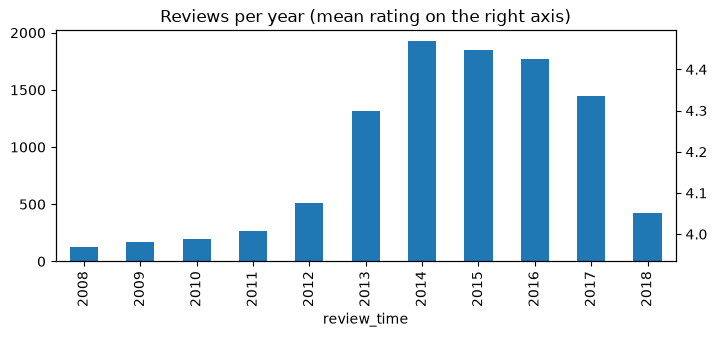

,count,mean
review_time,,
2013,1313,4.389947
2014,1924,4.404886
2015,1851,4.431118
2016,1772,4.426072
2017,1447,4.469247
2018,420,4.445238


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
review["review_time"] = pd.to_datetime(review["review_time"])
by_year = review.groupby(review["review_time"].dt.year)["rating"].agg(["count", "mean"])
ax = by_year["count"].plot(kind="bar", figsize=(8, 3), title="Reviews per year (mean rating on the right axis)")
by_year["mean"].plot(ax=ax.twinx(), color="tab:red", marker="o")
plt.show()
by_year.tail(6)

## 6 · A dashboard with two charts, then a public link

A recipe chart is deterministic (no AI, no credits): tables, a grouping, a measure — and a Top N when the grouping has thousands of values (the API refuses an unreadable axis with a clear message). The link is a **published** view — a frozen copy whose numbers still follow data refreshes.

In [7]:
tab = next((t for t in p.dashboards.list() if t.name == "Reviews"), None) or p.dashboards.create("Reviews")
tab.refresh()
have = {c.title for c in tab.charts}
if "Reviews by rating" not in have:
    tab.add_chart({"tables": ["review"], "chart_type": "bar", "group_by": [{"column": "rating"}],
                   "measure": {"agg": "count", "column": "rating"}}, title="Reviews by rating")
if "Most-reviewed brands (joined, top 10)" not in have:
    tab.add_chart({"tables": ["review", "product"], "chart_type": "bar", "group_by": [{"column": "brand"}],
                   "measure": {"agg": "count", "column": "rating"},
                   "joins": [{"table": "product", "left_column": "product_id", "right_column": "product_id"}],
                   "order_by": {"dir": "desc", "limit": 10}},                         # 6,000+ brands → Top 10
                  title="Most-reviewed brands (joined, top 10)")
tab.refresh()
for c in tab.charts:
    print(c.id, "·", c.title)

w-39637bbb · Reviews by rating
w-d67e2291 · Most-reviewed brands (joined, top 10)


In [8]:
chart = tab.charts[0]
page = chart.data(op="page", page_size=10)         # the widget's own data, as the dashboard shows it
pd.DataFrame(page["rows"])

,trace_idx,trace_name,trace_type,x,y,series,hovertext
0,0,trace0,bar,1,282,None,None
1,0,trace0,bar,2,358,None,None
2,0,trace0,bar,3,850,None,None
3,0,trace0,bar,4,2199,None,None
4,0,trace0,bar,5,6311,None,None


In [9]:
published = [s for s in tab.shares() if s.get("mode") == "published"]
link = published[0] if published else tab.share(mode="published")
token = link.get("token")
print("public link:", f"https://langsat.ai/shared/{token}" if token else f"(already published as share {link.get('share_id')} — the token is shown once, at creation)")

public link: https://langsat.ai/shared/LMQBNWmMNPjhD_OdFs14NZBBU41EmQjbMFPrTOy87sRSVJxfj0dXg5VAkxoYArY9


## 7 · Ask the data

One AI question against your quota. The answer carries the text, the execution kind (SQL / analysis) and any chart specs the model produced, which you can pin to a dashboard with `tab.add_chart_spec(...)`.

In [10]:
a = p.ask("Which year had the lowest average rating, and how many reviews were written that year?", timeout=300)
print(a.text)
print("\nexecution:", a.execution_kind, "· charts:", len(a.chart_specs))

## Year with Lowest Average Rating

**Year**: 2009
**Average rating**: 3.9593
**Number of reviews**: 172

execution: code · charts: 0


In [11]:
save_metrics(".", {"notebook": "01_setup_and_explore", "task": "setup + explore (no model)", "model": "—",
                   "project_id": p.id, "tables": {t["name"]: t["rows"] for t in p.tables.list()},
                   "foreign_keys": sr["schema_data"]["foreign_keys"], "charts": [c.title for c in tab.charts],
                   "headline": {"published_link": bool(token) or bool(published), "answer_chars": len(a.text)}})

wrote results/metrics.json


PosixPath('results/metrics.json')